

SOSYAL İHTİYAÇ TAHMİN MODELİ (SOCIAL NEEDS PREDICTION MODEL)

Proje Amacı: Bireylerin sadece gelirlerine değil; aile yapısı, iş durumu ve 
psikolojik tatminlerine bakarak "Gerçek İhtiyaç Sahiplerini" tespit etmek.

Hedef (Target) Mimarısi - Hibrit Puanlama (Eşik >= 4):
1. Gelir (realinc) en alt %25'lik dilimde: +2 Puan
2. İş Durumu (wrkstat) İşsiz(4) veya Çalışmıyor(3): +2 Puan
3. Çocuk Sayısı (childs) 3 veya daha fazla: +1 Puan
4. Finansal Tatmin (satfin) "Hiç tatmin değil"(3): +1 Puan
5. Sosyal Sınıf (class) "Alt Sınıf"(1): +1 Puan

-4 puan ve üstü ihtiyacı var(1) olarak kabul edilir.


Kullanılan Özellikler (Features):
educ (Eğitim), prestg10 (Saygınlık), age (Yaş), sex (Cinsiyet), 
region (Bölge), marital (Medeni Durum), natfare (Sosyal Yardım Algısı)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix
import joblib
import os
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix
!pip install imbalanced-learn
df = pd.read_csv('../data/processed/temiz_veri.csv')
df_sub = pd.read_csv('../data/processed/temiz_veri.csv')

1. VERİ HAZIRLIĞI VE EKSİK VERİ TAMAMLAMA

In [2]:
# Dosya yolunu kendi sistemine göre güncelle
df_sub = pd.read_csv('../data/processed/temiz_veri.csv') 

# İşlem yapılacak sütunları garanti altına alalım
kategorik_sutunlar = ['wrkstat', 'satfin', 'class', 'sex', 'region', 'marital', 'natfare', 'health']
sayisal_sutunlar = ['realinc', 'childs', 'educ', 'prestg10', 'age']

# Sadece veri setinde var olan sütunları seçelim (Hata almamak için)
mevcut_sutunlar = [col for col in kategorik_sutunlar + sayisal_sutunlar if col in df_sub.columns]
df_sub = df_sub[mevcut_sutunlar].copy()

# Sayısal boşlukları Medyan ile doldur
imputer_num = SimpleImputer(strategy='median')
df_sub[[col for col in sayisal_sutunlar if col in df_sub.columns]] = imputer_num.fit_transform(df_sub[[col for col in sayisal_sutunlar if col in df.columns]])

# Kategorik boşlukları Mode (En sık geçen) ile doldur
imputer_cat = SimpleImputer(strategy='most_frequent')
df_sub[[col for col in kategorik_sutunlar if col in df_sub.columns]] = imputer_cat.fit_transform(df_sub[[col for col in kategorik_sutunlar if col in df.columns]])

In [5]:
df_sub[['health', 'target_money']].corr()

KeyError: "['target_money'] not in index"

2. HİBRİT TARGET (HEDEF) İNŞASI

In [ ]:
# 1. Gelişmiş Hedef Değişkeni Oluşturma
df_sub['income_per_capita'] = df_sub['realinc'] / (df_sub['childs'] + 1)
ipc_30th = df_sub['income_per_capita'].quantile(0.30)

def calculate_need_score_v2(row):
    score = 0
    if row['income_per_capita'] <= ipc_30th:
        score += 2
    if row['wrkstat'] in [3, 4]:
        score += 2
    if row['class'] == 1 and row['satfin'] == 3:
        score += 2
    elif row['class'] == 1 or row['satfin'] == 3:
        score += 1
    return score

df_sub['need_score_v2'] = df_sub.apply(calculate_need_score_v2, axis=1)
df_sub['target_money'] = (df_sub['need_score_v2'] >= 3).astype(int)

# 2. X ve y Ayrımı (Atladığın kısım)
sizinti_yapan_sutunlar = [
    'realinc', 'wrkstat', 'childs', 'satfin', 'class', 
    'need_score', 'need_score_v2', 'income_per_capita', 
    'target_money', 'natfare'
]

X = df_sub.drop(columns=[col for col in sizinti_yapan_sutunlar if col in df_sub.columns])
y = df_sub['target_money']

# 3. Train-Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)   

print("İşlem başarılı. X_train boyutu:", X_train.shape)
print("Hedef dağılımı:\n", y.value_counts())

İşlem başarılı. X_train boyutu: (18124, 6)
Hedef dağılımı:
 target_money
0    18516
1     4140
Name: count, dtype: int64


In [ ]:
# Hem aracı skorları hem de kuralı yazarken kullandığımız orijinal kolonları siliyoruz
X = df_sub.drop(columns=[
    'target_money',         
    'realinc',           # Kuralın ana parçası
    'wrkstat',           # Kuralın ana parçası
    'childs',            # Kuralın ana parçası
    'satfin',            # Kuralın ana parçası
    'class'              # Kuralın ana parçası
], errors='ignore')

# Kontrol etmek için geriye kalan kolonları yazdır
print("Eğitim için geriye kalan temiz kolonlar:")
print(X.columns.tolist())

Eğitim için geriye kalan temiz kolonlar:
['sex', 'region', 'marital', 'natfare', 'educ', 'prestg10', 'age', 'income_per_capita', 'need_score_v2']


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Güvenlik Kontrolü: Sütun yoksa hemen oluştur
if 'target_money' not in df_sub.columns:
    if 'natfare' in df_sub.columns:
        df_sub['target_money'] = np.where(df_sub['natfare'] == 1, 1, 0)
    else:
        print("HATA: natfare sütunu da bulunamadı. Veriyi en baştan yüklemeniz gerekiyor.")

# 2. X ve y Ayrımı
sizinti_yapan_sutunlar = ['realinc', 'wrkstat', 'childs', 'satfin', 'class', 'need_score', 'target_money', 'natfare','need_score_v2', 'income_per_capita']

X = df_sub.drop(columns=[col for col in sizinti_yapan_sutunlar if col in df_sub.columns])
y = df_sub['target_money']

# 3. Train-Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)   

print("İşlem başarılı. X_train boyutu:", X_train.shape)

İşlem başarılı. X_train boyutu: (18124, 6)


####    KEŞİFÇİ VERİ ANALİZİ

4. İhtiyacı Olanlar ve Olmayanların Sayısını Gösteren Grafik (Genel Dağılım)

Veri setindeki %90'a %10'luk o devasa sınıf dengesizliğini jüriye göstermek için en iyi yöntem bir pasta grafiği (Pie Chart) kullanmaktır.

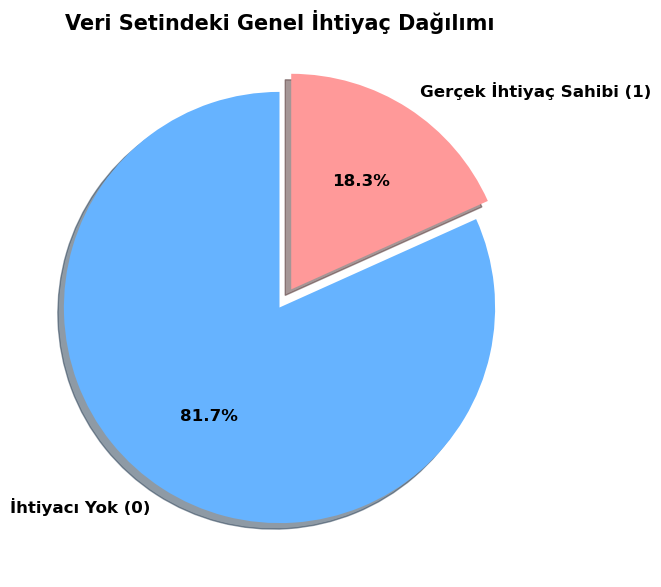

In [ ]:
# Hata almamak için df_sub ve sütun kontrolü
if 'df_sub' in locals() and 'target_money' in df_sub.columns:
    plt.figure(figsize=(7, 7))

    # Hedef değişkenin sayımlarını df_sub üzerinden alıyoruz
    durum_sayilari = df_sub['target_money'].value_counts()

    # Pasta grafiği çizimi
    plt.pie(durum_sayilari, 
            labels=['İhtiyacı Yok (0)', 'Gerçek İhtiyaç Sahibi (1)'], 
            autopct='%1.1f%%', 
            startangle=90, 
            colors=['#66b3ff', '#ff9999'], 
            explode=(0, 0.1), 
            shadow=True,
            textprops={'fontsize': 12, 'weight': 'bold'})

    plt.title('Veri Setindeki Genel İhtiyaç Dağılımı', fontsize=15, fontweight='bold')
    plt.show()
else:
    print("Hata: 'df_sub' tanımlı değil veya 'target_money' sütunu bulunamadı! Lütfen veriyi yüklediğinizden emin olun.")

1. Cinsiyete Göre Finansal Yardım İhtiyacı
Bu grafik, erkeklerin ve kadınların kendi içlerinde ne kadarının ihtiyaç sahibi olduğunu gösterir.

C:\Users\karac\AppData\Local\Temp\ipykernel_1180\1307259466.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_sub, x='sex', y='target_money', errorbar=None, palette='Set2')
C:\Users\karac\AppData\Local\Temp\ipykernel_1180\1307259466.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Kadın (0)', 'Erkek (1)'])


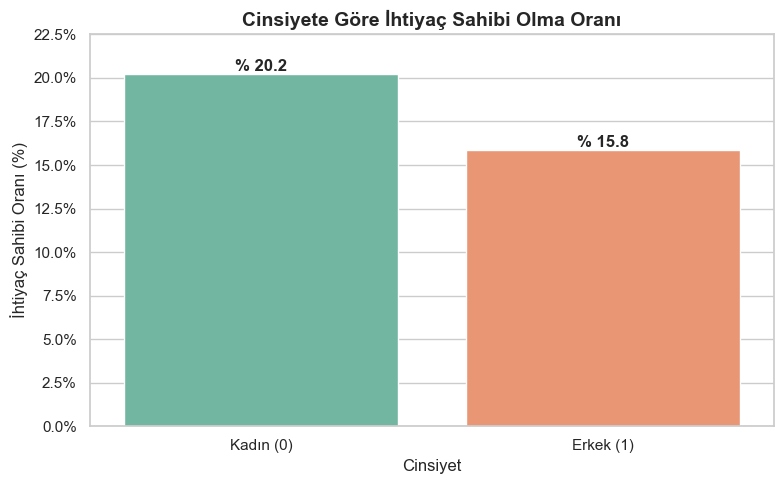

In [ ]:
# Güvenlik Kontrolü: df_sub var mı ve içinde target_money sütunu mevcut mu?
if 'df_sub' in locals() and 'target_money' in df_sub.columns:
    
    # GÖRSELLEŞTİRME
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 5))

    # df yerine asıl çalışma masamız olan df_sub tablosunu kullanıyoruz
    ax = sns.barplot(data=df_sub, x='sex', y='target_money', errorbar=None, palette='Set2')

    plt.title('Cinsiyete Göre İhtiyaç Sahibi Olma Oranı', fontsize=14, fontweight='bold')
    plt.xlabel('Cinsiyet', fontsize=12)
    plt.ylabel('İhtiyaç Sahibi Oranı (%)', fontsize=12)

    # Eksen etiketleri (Verimizde 0: Kadın, 1: Erkek olarak güncellemiştik)
    ax.set_xticklabels(['Kadın (0)', 'Erkek (1)']) 

    # Y-Eksenini yüzde formatına çevirme (Hata almamak için önce yticks sabitlenir)
    vals = ax.get_yticks()
    ax.set_yticks(vals)
    ax.set_yticklabels(['{:,.1f}%'.format(x*100) for x in vals])

    # Çubukların üzerine yüzde değerlerini yazdıralım
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'% {height*100:.1f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

else:
    print("❌ HATA: 'df_sub' tanımlı değil veya 'target_money' sütunu bulunamadı! Lütfen veriyi yüklediğiniz hücreyi çalıştırın.")

2. Çocuk Sayısına Göre Finansal Yardım İhtiyacı
Çocuk sayısı arttıkça finansal yükün nasıl arttığını (bizim kurduğumuz mantığın nasıl çalıştığını) kanıtlayan grafiktir.

C:\Users\karac\AppData\Local\Temp\ipykernel_1180\1503071674.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_sub, x='childs', y='target_money', errorbar=None, palette='viridis')


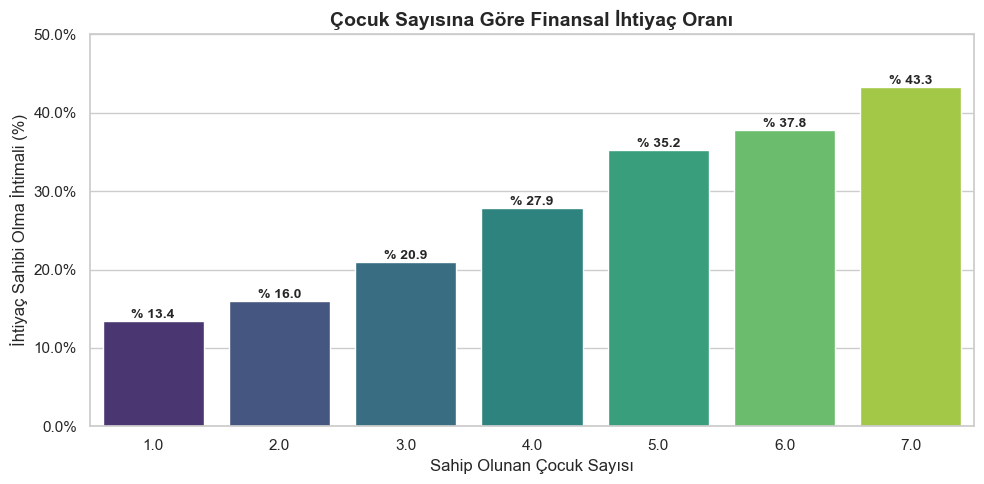

In [ ]:
# 1. GÜVENLİK KONTROLÜ: df_sub var mı ve içinde target_money sütunu mevcut mu?
if 'df_sub' in locals() and 'target_money' in df_sub.columns:
    
    # 2. GRAFİK ÇİZİMİ
    plt.figure(figsize=(10, 5))
    
    # Veri kaynağı olarak df yerine df_sub kullanıyoruz
    ax = sns.barplot(data=df_sub, x='childs', y='target_money', errorbar=None, palette='viridis')

    plt.title('Çocuk Sayısına Göre Finansal İhtiyaç Oranı', fontsize=14, fontweight='bold')
    plt.xlabel('Sahip Olunan Çocuk Sayısı', fontsize=12)
    plt.ylabel('İhtiyaç Sahibi Olma İhtimali (%)', fontsize=12)

    # Y-Eksenini yüzde formatına çevirme (Uyarı almamak için yticks sabitlenir)
    vals = ax.get_yticks()
    ax.set_yticks(vals)
    ax.set_yticklabels(['{:,.1f}%'.format(x*100) for x in vals])

    # Çubukların üzerine yüzde değerlerini yazdıralım
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Sadece 0'dan büyük olanları yazdır (görsel kirliliği önler)
            ax.annotate(f"% {height*100:.1f}", 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

else:
    print("❌ HATA: 'df_sub' tanımlı değil veya 'target_money' sütunu bulunamadı!")
    print("ÇÖZÜM: Lütfen veriyi yüklediğiniz ve hedef değişkeni oluşturduğunuz ana hücreyi çalıştırın.")

3. Irk Gruplarına Göre Finansal Yardım İhtiyacı

 Farklı etnik grupların finansal kırılganlıklarını karşılaştırmak için kullanılır (GSS verisinde genellikle 1: Beyaz, 2: Siyah, 3: Diğer olarak kodlanır).

C:\Users\karac\AppData\Local\Temp\ipykernel_1180\2767631107.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_sub, x='race', y='target_money', errorbar=None, palette='magma')
C:\Users\karac\AppData\Local\Temp\ipykernel_1180\2767631107.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Beyaz (1)', 'Siyah (2)', 'Diğer (3)'])


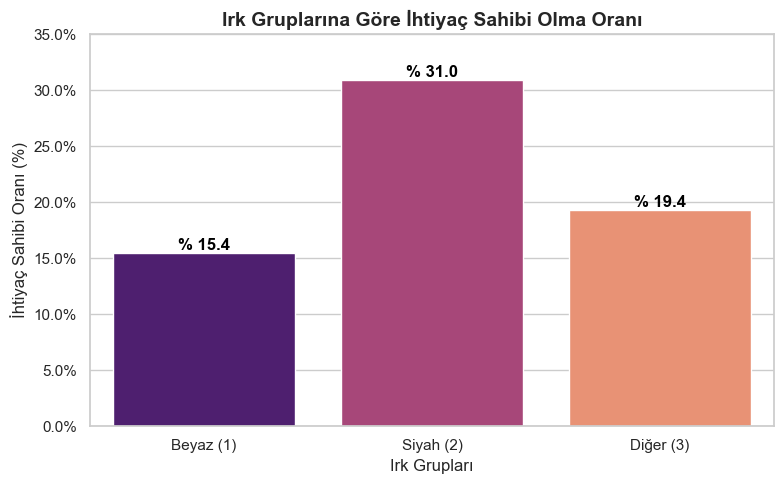

In [ ]:
# 1. GÜVENLİK KONTROLÜ: df_sub var mı ve içinde target_money sütunu mevcut mu?
if 'df_sub' in locals() and 'target_money' in df_sub.columns:
    
    # 'race' sütununu orijinal dosyadan çekip df_sub'a ekliyoruz
    # (Eğer model sızıntısı yapmasın diye daha önce sildiysen, sadece görselleştirme için geri alıyoruz)
    df_orijinal = pd.read_csv('../data/processed/temiz_veri.csv')
    df_sub['race'] = df_orijinal['race']

    # 2. GRAFİK ÇİZİMİ
    plt.figure(figsize=(8, 5))
    sns.set_theme(style="whitegrid")

    # Veri kaynağı olarak df yerine df_sub kullanıyoruz ve ci=None güncellendi
    ax = sns.barplot(data=df_sub, x='race', y='target_money', errorbar=None, palette='magma')

    plt.title('Irk Gruplarına Göre İhtiyaç Sahibi Olma Oranı', fontsize=14, fontweight='bold')
    plt.xlabel('Irk Grupları', fontsize=12)
    plt.ylabel('İhtiyaç Sahibi Oranı (%)', fontsize=12)

    # X ekseni etiketlerini düzeltme
    ax.set_xticklabels(['Beyaz (1)', 'Siyah (2)', 'Diğer (3)'])

    # Y-Eksenini yüzde formatına çevirme (Uyarı almamak için yticks sabitlenir)
    vals = ax.get_yticks()
    ax.set_yticks(vals)
    ax.set_yticklabels(['{:,.1f}%'.format(x*100) for x in vals])

    # Yüzdeleri çubukların üzerine yazdırma
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Sadece 0'dan büyük olanları yazdır
            ax.annotate(f"% {height*100:.1f}", 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', fontsize=12, color='black', fontweight='bold')

    plt.tight_layout()
    plt.show()

else:
    print("❌ HATA: 'df_sub' tanımlı değil veya 'target_money' sütunu bulunamadı!")
    print("ÇÖZÜM: Lütfen veriyi yüklediğiniz ve hedef değişkeni oluşturduğunuz ana hücreyi çalıştırın.")

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300, 
    max_depth=8, 
    class_weight='balanced_subsample', 
    random_state=42
)
rf_model.fit(X_train, y_train)

# Dinamik Eşik (Threshold) Testi
y_pred = rf_model.predict_proba(X_test)[:, 1]
# Yeni puanlama sistemine göre eşiği ayarlıyoruz
final_score = balanced_accuracy_score(y_test, (y_pred >= 0.45).astype(int))

print(f"--- YENİ HİBRİT MODEL SONUCU ---")
print(f"Veri Seti Boyutu: {df.shape}")
print(f"Hedef (1) Olanların Sayısı: {y.sum()}")
print(f"Balanced Accuracy: {final_score:.4f}")

--- YENİ HİBRİT MODEL SONUCU ---
Veri Seti Boyutu: (22656, 20)
Hedef (1) Olanların Sayısı: 4140
Balanced Accuracy: 0.6888


In [ ]:
from sklearn.metrics import classification_report

# Modelin test seti üzerindeki tahminlerini al
y_pred = rf_model.predict(X_test)

# Detaylı raporu yazdır
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.67      0.77      3704
           1       0.32      0.69      0.44       828

    accuracy                           0.68      4532
   macro avg       0.61      0.68      0.60      4532
weighted avg       0.80      0.68      0.71      4532



In [ ]:
from lazypredict.Supervised import LazyClassifier

print("🚀 LazyClassifier başlatıldı. 30'a yakın algoritma birbiriyle yarışıyor, lütfen bekleyin...")

# Sınıf dengesizliği olduğu için modellerin temel ayarlarında çalışacak
# random_state=42 ile modellerin rastgelelik başlangıç noktası sabitlendi
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None, random_state=42)

# Tüm modelleri aynı X_train ve y_train ile eğit, test verisinde sına
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print("\n🏆 --- LAZY PREDICT LİDERLİK TABLOSU (İLK 10) --- 🏆")
print(models.head(10))

🚀 LazyClassifier başlatıldı. 30'a yakın algoritma birbiriyle yarışıyor, lütfen bekleyin...

🏆 --- LAZY PREDICT LİDERLİK TABLOSU (İLK 10) --- 🏆
                             Accuracy  Balanced Accuracy   ROC AUC  F1 Score  \
Model                                                                          
NearestCentroid              0.652692           0.665619  0.722190  0.691426   
PassiveAggressiveClassifier  0.703222           0.657615  0.720364  0.730973   
Perceptron                   0.714475           0.633085  0.698031  0.736485   
ExtraTreeClassifier          0.756178           0.569980  0.575010  0.750436   
ExtraTreesClassifier         0.786628           0.567510  0.669634  0.765407   
DecisionTreeClassifier       0.740291           0.566826  0.571634  0.740715   
RandomForestClassifier       0.795455           0.561656  0.695140  0.767262   
KNeighborsClassifier         0.793469           0.558097  0.656634  0.764904   
LabelPropagation             0.780229           0.557031 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report

# 1. Modeli sınıf dengesizliğini çözecek şekilde tanımla
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# 2. Random Forest için anlamlı hiperparametre havuzu
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# 3. Optimizasyon nesnesini oluştur
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,          # 15 farklı rastgele kombinasyon dene
    scoring='f1',       # Dengesiz veri için F1 skorunu baz al
    cv=5,               # 5 katlı çapraz doğrulama
    random_state=42,
    n_jobs=-1           # Hız için tüm işlemci çekirdeklerini kullan
)

# 4. Modeli eğit
print("Random Forest optimizasyonu yapılıyor, lütfen bekleyin...")
random_search.fit(X_train, y_train)

# 5. En iyi modelle tahmin yap ve sonuçları gör
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)



# Modelin Sınıf 1 için ürettiği olasılıkları al
y_probs = best_rf.predict_proba(X_test)[:, 1]

# Karar eşiğini 0.5'ten 0.3'e çek (Şüphe eşiğini düşür)
custom_threshold = 0.3
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# Yeni tahminlerle sonuçları yazdır
print("\nEn İyi Hiperparametreler:", random_search.best_params_)
print("\nTest Seti Performansı:\n", classification_report(y_test, y_pred))

Random Forest optimizasyonu yapılıyor, lütfen bekleyin...

En İyi Hiperparametreler: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 5, 'bootstrap': True}

Test Seti Performansı:
               precision    recall  f1-score   support

           0       0.91      0.64      0.75      3704
           1       0.31      0.73      0.44       828

    accuracy                           0.66      4532
   macro avg       0.61      0.69      0.60      4532
weighted avg       0.80      0.66      0.70      4532



----------

In [ ]:
print("Modelin kullandığı sütunlar:", X_train.columns.tolist())

Modelin kullandığı sütunlar: ['sex', 'region', 'marital', 'educ', 'prestg10', 'age']
